# CNN-based multiclass classifier

### Description


Experiment 6 (Appendix): ModelCNNExp1_6

The model is ModelCNNExp1_6 with more complex architecture. The model employed another type of Pooling layer (GlobalAveragePooling2D) instead of normal flattern layer.
- The model was trained with class_weights to tackle imbalanced dataset. The class weights were computed by train data disibution and feed into model optimiser.
- Input normalisation is the only data preprocessing technique applied (for all train, val, and test data).
- Light data augmentation was applied for both train and valid data.
- The optimiser is Adamax, with a loss function of categorical_crossentropy. The metrics are accuracy. The learning rate scheduler is Cosine decay, with an initial LR of 0.001, a decay steps ratio of 0.75, and an alpha of 0.1.
- The model was fully trained for two rounds: In the first round, it was trained for 200 epochs with a batch size of 16 for the first round; In the second round, it was trained for another 100 epochs with batch size 16 and stronger data augmentation. 

In [1]:
# ============
## TIMESTAMP @ 2024-11-07T16:34:02

# Exp with transfer learning approach
# Pretrained weight from Imagenet
# Optimizer: AdamW, Adamax
"""
Experiment Code:
Model: ModelCNNExp1 
Pretrained weights: imagenet
Training type: Training all layers.
Output layers: 
Regularizer layer: Dropout
Data augmentation: Yes
Optimizer: Adamax
LearningRate Scheduler: Consine decay
LearningRate Scheduler opt: 0.9, 0.1
epochs: 100
batchsize: 16
"""
# Import necessary libs

import os, io
import datetime
import time
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import logging
import random
import string
# These lib should be placed at the same level at the notebook
import dev_configuration
import dev_dataprocesses
import itertools

2024-12-20 04:34:05.966626: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-20 04:34:05.966645: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-20 04:34:05.966651: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-20 04:34:05.970520: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
## Configuration

In [3]:
randomState_value = 2024

# Dataset configuration
datasets  = ['chest_xray_small', 'chest-xray-full', 'sport-balls']
dataset_name = 'sport-balls'
dataset_original_path = f"./datasets/{dataset_name}/"
test_split_value = 0.2 # split ratio of test from the given data source
val_split_value = 0.3 # split ratio of validation from the given data source
# keras datagenerators configuration
default_xcol_value = 'filepath'
default_ycol_value = 'label'
isShuffle = True

# Debug flags
# legacy flags
isDebug = False
isVerbose = True
is_config_exp = False # Disable model archs definition list
# Image size configuration
# legacy
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
# Model configuration
# Learning configuration
model_loss_opt = 'categorical_crossentropy'
learning_rate = 0.001
# learning cosine decay rate
decay_rate = 0.75
decay_alpha_value = 0.1

# default setting for long run
enableEarlyStopping = False
enableEarlyStopping_threshold = 10
epochs = 200
batch_size = 32 # GPU RAM should be at least 24GB
if isDebug:
    # Debug run
    epochs = 10
    batch_size = 16
else:
    # Normal run
    epochs = 200
    batch_size = 16 # Run on small gpu portion
# for transfer learning/finetuning
pretrained_weights = 'imagenet' # Pretrained weights
frozen_weights = False # True: Freeze all base layers. False: otherwise.
# For regulariser layers
kernel_l_value = 0.001
act_l_value = 0.001
drop_out_value_1 = 0.5
drop_out_value_2 = 0.3
drop_out_value_3 = 0.1
models_archs = ['ModelCNNExp1', 'ModelCNNExp2', 'ModelCNNExp3', 'ModelCNNExp4']

In [4]:
# Logging and artifacts configuration
# Generate unique exp string
digits = random.choices(string.digits, k=2)
letters = random.choices(string.ascii_uppercase, k=9)
uniq_sample = f"".join(random.sample(digits + letters, 9))

# Setting up folders and logging
exp_base_dir = f"./experiments/"
model_sel = 'ModelCNNExp1'
# configurations for output layers after base-layer
config_output_arc = 'config_5'

augmentation_opts = {
            'rescale': 1./255., # Remember to set None if model is EfficientNet
            'rotation_range': 0,
            'width_shift_range': 0.0,
            'height_shift_range': 0.0,
            'zoom_range': 0.0,
            'horizontal_flip': True,
            'vertical_flip': True,
        }
if model_sel == 'EfficientNetB3':
    augmentation_opts['rescale'] = None

#augmentation_options = f"rescale width_shift_range height_shift_range zoom_range horizontal_flip=True vertical_flip=True"
augmentation_options = f"".join([f"{key}_{augmentation_opts[key]}_" for key in augmentation_opts.keys()])

# augmentation_options = f"augs_rescale rot=no horizontal_flip=True vertical_flip=True"
#augmentation_options = f"augs_rescale rot=no horizontal_flip=no vertical_flip=no"
other_options = (f"_no_pool_in_base_{config_output_arc}_activity_reg_{act_l_value}_kernel_reg_{kernel_l_value}_dropout_0.3_0.3"
                 f"\nlearning rate decay: Adamax, "
                 f"\n decay_rate_{decay_rate}_alpha_{decay_alpha_value}")


In [5]:
## Preparation

In [6]:
current_datestamp = datetime.datetime.now().strftime("%Y%m%d")
exp_folder = f"{model_sel}-{current_datestamp}_{uniq_sample}"

logs_text_dir = os.path.join(exp_base_dir, exp_folder, "logs")
checkpoints_dir = os.path.join(exp_base_dir, exp_folder, "checkpoints")

current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
log_filename = f"{logs_text_dir}/{model_sel}-{current_timestamp}.log"

if not os.path.exists(checkpoints_dir):
    os.makedirs(checkpoints_dir, exist_ok=True)

if not os.path.exists(logs_text_dir):
    os.makedirs(logs_text_dir, exist_ok=True)

# Create a logger
logger = logging.getLogger('my_logger')
logger.setLevel(logging.DEBUG)

# Create a formatter to define the log format
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')

# Create a file handler to write logs to a file
file_handler = logging.FileHandler(log_filename)
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(formatter)

# Create a stream handler to print logs to the console
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)  # You can set the desired log level for console output
console_handler.setFormatter(formatter)

# Add the handlers to the logger
logger.addHandler(file_handler)
logger.addHandler(console_handler)

logger.info(f"Datetime: {current_timestamp}"
            f"\n Setup all folders and files:"
            f"\n Unique expname: {uniq_sample}"
            f"\n exp_folder: {exp_folder}"
            f"\n -logs_text_dir dir: {logs_text_dir}"
            f"\n -checkpoints_dir : {checkpoints_dir}")


2024-12-20 04:34:07,720 - INFO - Datetime: 20241220-043407
 Setup all folders and files:
 Unique expname: WYL2LDPVR
 exp_folder: ModelCNNExp1-20241220_WYL2LDPVR
 -logs_text_dir dir: ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/logs
 -checkpoints_dir : ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/checkpoints


In [7]:
## Helpers function

In [8]:
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Oranges,
                          figname='figname.png'):
    plt.figure(figsize=(10, 10))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized Confusion Matrix')
    else:
        print('Confusion Matrix, Without Normalization')
    print(cm)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment='center', color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(fig_name)

def get_model_summary(model):
    stream = io.StringIO()
    model.summary(print_fn=lambda x: stream.write(x + '\n'))
    summary_string = stream.getvalue()
    stream.close()
    return summary_string

class LearningRateLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = self.model.optimizer.learning_rate
        if isinstance(lr, tf.keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(self.model.optimizer.iterations)
        logs['learning_rate'] = float(tf.keras.backend.get_value(lr))

In [9]:
# Generate data for training

In [10]:
## Data preparation

In [11]:
loaded_datasets = dev_dataprocesses.load_dataset(preconfigured_dataset=dataset_name)

train_data, val_data, test_data = dev_dataprocesses.data_generators(
    datasource=loaded_datasets,
    data_generator='keras',
    test_split_value = test_split_value,
    val_split_value = val_split_value,
    randomState_value = randomState_value,
    default_xcol_value = default_xcol_value,
    default_ycol_value = default_ycol_value,
    batch_size = batch_size,
    isShuffle = isShuffle,
    augmentation_opts = augmentation_opts
)

Processing ./datasets/sport-balls
Processing train set
Processing test set
 processes completed
 3

 Label: train 
Length is : 7328
Sample head: 
                                             filepath     label
0  ./datasets/sport-balls/train/baseball/baseball...  baseball
1  ./datasets/sport-balls/train/baseball/baseball...  baseball
2  ./datasets/sport-balls/train/baseball/baseball...  baseball
3  ./datasets/sport-balls/train/baseball/baseball...  baseball
4  ./datasets/sport-balls/train/baseball/baseball...  baseball
Sample shape: 
 (7328, 2)
Value counts: 
 label
billiard_ball        646
table_tennis_ball    620
football             604
cricket_ball         581
golf_ball            549
hockey_ball          530
rugby_ball           493
tennis_ball          490
bowling_ball         440
volleyball           432
shuttlecock          429
baseball             400
hockey_puck          390
american_football    384
basketball           340
Name: count, dtype: int64==================

 Label:

In [12]:
from sklearn.utils import class_weight
import numpy as np
unique_classes = np.unique(train_data.classes)
class_weights_np = class_weight.compute_class_weight(class_weight = 'balanced', classes = unique_classes,y=train_data.classes)
class_weights = {l:c for l,c in zip(unique_classes, class_weights_np)}

In [13]:
## Models definition

In [14]:
class_weights_np

array([1.30508906, 1.16700796, 1.3622842 , 0.7417209 , 1.14358974,
       0.81219319, 0.80835303, 0.88354866, 0.94718375, 1.27112763,
       0.99399225, 1.20824499, 0.78786482, 0.99111111, 1.15518018])

In [15]:
class_weights

{0: 1.305089058524173,
 1: 1.1670079635949944,
 2: 1.3622841965471448,
 3: 0.7417208966015908,
 4: 1.1435897435897435,
 5: 0.8121931908155187,
 6: 0.8083530338849487,
 7: 0.8835486649440137,
 8: 0.9471837488457987,
 9: 1.2711276332094177,
 10: 0.9939922480620155,
 11: 1.2082449941107185,
 12: 0.7878648233486943,
 13: 0.9911111111111112,
 14: 1.1551801801801802}

In [16]:
# Model arch library
# Customized model arch


In [17]:
logger.info(f"Training {model_sel} model  with new configuration")

if model_sel == 'VGG16':
    base_model = keras.applications.VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
    )
elif model_sel == 'VGG19':
    base_model = keras.applications.VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=img_shape,
    )
elif model_sel == 'EfficientNetB3':
    base_model = keras.applications.EfficientNetB3(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        # pooling='max'
    )
# elif model_sel == 'ModelCNNExp1':
#     base_model = ModelCNNExp1
# elif model_sel == 'ModelCNNExp2':
#     base_model = ModelCNNExp1
# elif model_sel == 'ModelCNNExp3':
#     base_model = ModelCnnExp3
# elif model_sel == 'ModelCNNExp4':
#     base_model = ModelCnnExp4
else:
    base_model = keras.applications.VGG19(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
    )

# if model_sel == 'ModelCNNExp1' or model_sel == 'ModelCNNExp2':
if model_sel == 'ModelCNNExp1':
    logger.info(f"Training {model_sel} model  from scratch")
    model_new = keras.models.Sequential([
        keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=img_shape),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),

        # Second block
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

        # Third block
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),

# Fourth block
        keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        keras.layers.BatchNormalization(),
        keras.layers.MaxPooling2D((2, 2)),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(1024, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)),
        keras.layers.Dropout(0.4),
# keras.layers.Dense(15, activation='softmax'),



        

        # base_model,
        # keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3), activation='relu', input_shape=img_shape),
        # keras.layers.BatchNormalization(),
        # keras.layers.Conv2D(filters=256, kernel_size=(5, 5), strides=(1, 1), activation='relu', padding="same"),
        # keras.layers.BatchNormalization(),
        # keras.layers.MaxPool2D(pool_size=(3, 3)),

        # keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        # keras.layers.BatchNormalization(),
        # keras.layers.MaxPool2D(pool_size=(2, 2)),

        # keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        # keras.layers.BatchNormalization(),
        # keras.layers.Conv2D(filters=512, kernel_size=(3, 3), activation='relu', padding="same"),
        # keras.layers.BatchNormalization(),
        # keras.layers.MaxPool2D(pool_size=(2, 2)),

        # keras.layers.Flatten(),

        # keras.layers.Dense(1024, activation='relu'),
        ## TIMESTAMP @ 2024-12-13T17:52:43
        ## author: phuocddat
        ## start
        # Add regularizers layers to reduce overfitting
        # keras.layers.Dropout(drop_out_value_2), # medium dropout
        # keras.layers.Dense(512, activation='relu',
        #                    kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
        #                    activity_regularizer=keras.regularizers.l1(l=act_l_value)),
        # keras.layers.Dropout(drop_out_value_2), # medium dropout
        ## end --
        keras.layers.Dense(15, activation='softmax')
    ])
##
## Removed other types of model archs which are not as efficient as the ModelCNNEXp1
## ====
elif model_sel == 'EfficientNetB3':
    if frozen_weights:
        logger.info(f"Perform training with frozen weight with {model_sel}")
    else:
        logger.info(f"Perform training with no pretrained-weights {model_sel}")

    # Freeze pretrained weight from base_model layers.
    ## TIMESTAMP @ 2024-12-15T16:45:03
    ## author: phuocddat
    ## start
    # Disable trainable setting - default
    # base_model.trainable = False
    ## end --

    logger.info(f"Processing {model_sel} with {config_output_arc} for output block")
    if config_output_arc == 'config_1':
        model_new = keras.models.Sequential([
            base_model,
            # Config 1
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            keras.layers.Dense(256, activation='relu'),
            keras.layers.Dense(64, activation='relu'),
            keras.layers.Dense(32, activation='relu'),
            keras.layers.Dense(15, activation='softmax')
        ])
    elif config_output_arc == 'config_2':
        model_new = keras.models.Sequential([
            base_model,
            # Config 2
            ## TIMESTAMP @ 2024-12-12T10:38:52
            ## author: phuocddat
            ## start
            ## end --
            keras.layers.BatchNormalization(),
            keras.layers.Dense(256,
                               # kernel_regularizer=keras.regularizers.l2(0.001),
                               # activity_regularizer=keras.regularizers.l1(0.001),
                               activation='relu', ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout - 0.3
            keras.layers.Dense(15, activation="softmax")
        ])
    elif config_output_arc == 'config_3':
        model_new = keras.models.Sequential([
            base_model,
            # Config 3
            # Add regularizers to reduce overfitting
            keras.layers.Dense(512, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout - 0.5
            keras.layers.Dense(15, activation='softmax')
            ## end --
        ])
    elif config_output_arc == 'config_4':
        model_new = keras.models.Sequential([
            base_model,
            # Config 4
            # Add regularizes to reduce overfitting
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            keras.layers.Dense(512, activation='relu',
                               #kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               #activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(0.3),
            keras.layers.Dense(15, activation='softmax')
        ])
    elif config_output_arc == 'config_5':
        model_new = keras.models.Sequential([
            # Config 5
            base_model,
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(512, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout
            keras.layers.Dense(256, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy drop out
            keras.layers.Dense(64, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            ## end --
            keras.layers.Dense(15, activation='softmax')
        ])
    else:
        logger.info(f"Not implemented {config_output_arc}")
        logger.info(f"Using one of drafting version below")
        model_new = keras.models.Sequential([
            # Config 5
            base_model,
            keras.layers.Flatten(),
            keras.layers.Dense(1024, activation='relu'),
            # keras.layers.Dropout(0.3),
            keras.layers.Dense(512, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy dropout
            keras.layers.Dense(256, activation='relu',
                               # kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               # activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_1), # heavy drop out
            keras.layers.Dense(64, activation='relu',
                               kernel_regularizer=keras.regularizers.l2(l=kernel_l_value),
                               activity_regularizer=keras.regularizers.l1(l=act_l_value)
                               ),
            keras.layers.Dropout(drop_out_value_2), # medium dropout
            ## end --
            keras.layers.Dense(15, activation='softmax')
        ])
else:
    if frozen_weights:
        logger.info(f"Perform training with frozen weight with {model_sel}")
    else:
        logger.info(f"Perform training with no pretrained-weights {model_sel}")
    # Freeze pretrained weight from base_model layers.
    # base_model.trainable = not frozen_weights
    model_new = keras.models.Sequential([
        base_model,
        # Config 1
        keras.layers.Flatten(),
        keras.layers.Dense(1024, activation='relu'),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(15, activation='softmax')
    ])


2024-12-20 04:34:07,922 - INFO - Training ModelCNNExp1 model  with new configuration
2024-12-20 04:34:08.168798: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-20 04:34:08.192284: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-12-20 04:34:08.196273: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. S

In [18]:
## Learning strategies

In [19]:
total_steps = len(train_data) * epochs
decay_steps = total_steps * decay_rate
logger.info(f"Total steps: {total_steps}"
      f"\n_decay steps: {decay_steps}")

cosine_decay_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=decay_steps,
    alpha=decay_alpha_value
)

2024-12-20 04:34:09,105 - INFO - Total steps: 64200
_decay steps: 48150.0


In [20]:
## Compile and fit

In [21]:
current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
exp_save_name = (f"{current_timestamp}___"
                 f"model_{model_sel}_{config_output_arc}_{pretrained_weights}_frozen_"
                 f"Adamax_bs_{batch_size}_frozen_{str(frozen_weights)}_cosine__aug")
checkpoint_path = f"{exp_save_name}.h5"
logger.info(f"epochs {dev_configuration.epochs}"
            f"\n batch size = {batch_size}"
            f"\n other options: {other_options} "
            f"\n augmentation: {augmentation_options}"
            f"\n Checkpoint: {checkpoint_path}")

my_callbacks = [
    # keras.callbacks.EarlyStopping(patience=enableEarlyStopping_threshold) if enableEarlyStopping else None,
    LearningRateLogger(),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
]
# Exp model training

2024-12-20 04:34:09,137 - INFO - epochs 200
 batch size = 16
 other options: _no_pool_in_base_config_5_activity_reg_0.001_kernel_reg_0.001_dropout_0.3_0.3
learning rate decay: Adamax, 
 decay_rate_0.75_alpha_0.1 
 augmentation: rescale_0.00392156862745098_rotation_range_0_width_shift_range_0.0_height_shift_range_0.0_zoom_range_0.0_horizontal_flip_True_vertical_flip_True_
 Checkpoint: 20241220-043409___model_ModelCNNExp1_config_5_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug.h5


In [22]:
model_new.compile(optimizer=tf.optimizers.Adamax(learning_rate=cosine_decay_scheduler),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
model_summary_string = get_model_summary(model_new)
logger.info(model_summary_string)

start_time = time.time()

training_exper_model_eff = model_new.fit(train_data,
                                         epochs=epochs,
                                         validation_data=val_data,
                                         verbose=1,
                                         callbacks=my_callbacks,
                                         class_weight=class_weights,
                                         #use_multiprocessing = True
                                         )
logger.info(f"Training finished in {time.time() - start_time} seconds")

2024-12-20 04:34:09,391 - INFO - Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 64)      1792      
                                                                 
 batch_normalization (Batch  (None, 222, 222, 64)      256       
 Normalization)                                                  
                                                                 
 conv2d_1 (Conv2D)           (None, 222, 222, 64)      36928     
                                                                 
 batch_normalization_1 (Bat  (None, 222, 222, 64)      256       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 64)      0         
 D)                                                              
                       

Epoch 1/200


2024-12-20 04:34:11.041635: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2024-12-20 04:34:12.044649: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7a7af4cabd90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-12-20 04:34:12.044665: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2024-12-20 04:34:12.047492: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-12-20 04:34:12.106297: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


321/321 [==============================] - 27s 67ms/step - loss: 2.7649 - accuracy: 0.1679 - val_loss: 2.8988 - val_accuracy: 0.0869 - learning_rate: 9.9990e-04
Epoch 2/200


/home/phuocddat/git-repo/msc_ai/chest_xray/env_chest_xray/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


321/321 [==============================] - 20s 61ms/step - loss: 2.5163 - accuracy: 0.2287 - val_loss: 2.5184 - val_accuracy: 0.2533 - learning_rate: 9.9961e-04
Epoch 3/200
321/321 [==============================] - 20s 63ms/step - loss: 2.4041 - accuracy: 0.2726 - val_loss: 2.6656 - val_accuracy: 0.2251 - learning_rate: 9.9911e-04
Epoch 4/200
321/321 [==============================] - 20s 63ms/step - loss: 2.3341 - accuracy: 0.3042 - val_loss: 2.3292 - val_accuracy: 0.3033 - learning_rate: 9.9842e-04
Epoch 5/200
321/321 [==============================] - 20s 63ms/step - loss: 2.2882 - accuracy: 0.3168 - val_loss: 2.5485 - val_accuracy: 0.2797 - learning_rate: 9.9754e-04
Epoch 6/200
321/321 [==============================] - 20s 63ms/step - loss: 2.2401 - accuracy: 0.3340 - val_loss: 2.3740 - val_accuracy: 0.2906 - learning_rate: 9.9646e-04
Epoch 7/200
321/321 [==============================] - 20s 63ms/step - loss: 2.1928 - accuracy: 0.3361 - val_loss: 2.3563 - val_accuracy: 0.2951 - 

2024-12-20 05:40:44,374 - INFO - Training finished in 3994.9826204776764 seconds


In [23]:
## Evaluating
# Full Evaluate model
ts_length = len(test_data)
test_batch_size = max(
    sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length % n == 0 and ts_length / n <= 80]))
test_steps = ts_length // test_batch_size

train_score = model_new.evaluate(train_data, steps=test_steps, verbose=1)
valid_score = model_new.evaluate(val_data, steps=test_steps, verbose=1)
test_score = model_new.evaluate(test_data, steps=test_steps, verbose=1)
print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

2/2 [==============================] - 0s 38ms/step - loss: 1.7007 - accuracy: 0.6875
Train Loss:  0.09548231959342957
Train Accuracy:  1.0
--------------------
Validation Loss:  2.487522840499878
Validation Accuracy:  0.78125
--------------------
Test Loss:  1.7006587982177734
Test Accuracy:  0.6875


In [24]:
## Plots and results

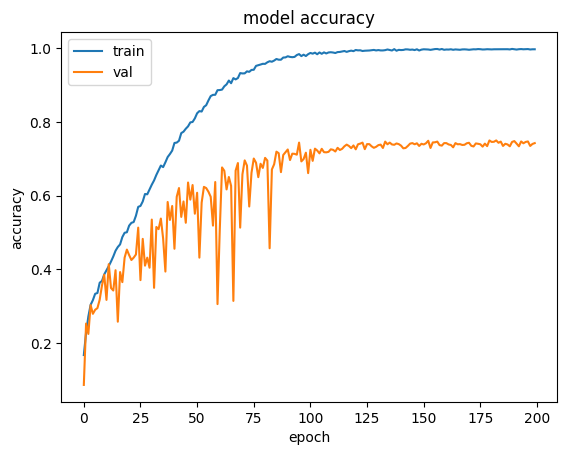

2024-12-20 05:40:45,091 - INFO - Export plot results: ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/logs/20241220-054044_aug_model_ModelCNNExp1_imagenet_frozen_False_ep200_bs_32_acc_tr1.0_va0.78125_te0.6875_accuracy_plot.png


In [25]:
metrics_string = f"acc_tr{train_score[1]}_va{valid_score[1]}_te{test_score[1]}"

current_timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_"
            f"{metrics_string}_"
            f"accuracy_plot.png")

plt.plot(training_exper_model_eff.history['accuracy'])
plt.plot(training_exper_model_eff.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.savefig(fig_name)
plt.show()

logger.info(f"Export plot results: {fig_name}")

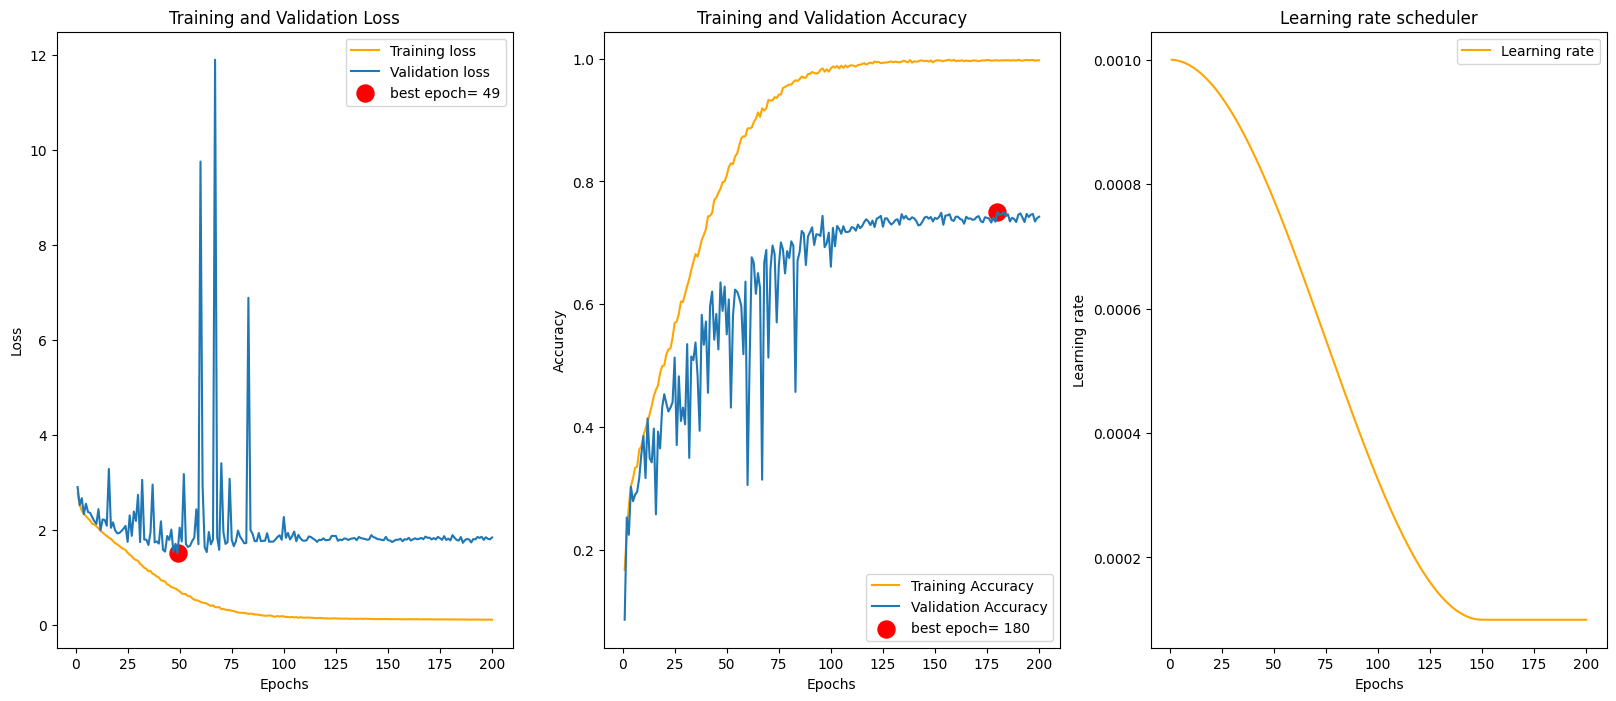

2024-12-20 05:40:45,612 - INFO - Export plot results: ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/logs/20241220-054044_aug_model_ModelCNNExp1_imagenet_frozen_False_ep200_bs_32_cosine_decay_scheduler_accuracy_loss_acc_tr1.0_va0.78125_te0.6875_plots.png
2024-12-20 05:40:45,613 - INFO - Train loss: 0.09548231959342957
Train Accuracy: 1.0
Validation loss: 2.487522840499878
Validation Accuracy: 0.78125
Test Loss: 1.7006587982177734
Test Accuracy: 0.6875


In [26]:
# Plot
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_plots.png")
# Define needed variables
tr_acc = training_exper_model_eff.history['accuracy']
tr_loss = training_exper_model_eff.history['loss']
val_acc = training_exper_model_eff.history['val_accuracy']
val_loss = training_exper_model_eff.history['val_loss']

learning_rate_logs = training_exper_model_eff.history['learning_rate']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
# index_lr = np.argmin(learning_rate)

loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

Epochs = [i + 1 for i in range(len(tr_acc))]

# Plot training history
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.plot(Epochs, tr_loss, 'orange', label='Training loss')
plt.plot(Epochs, val_loss, label='Validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c='red', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(Epochs, tr_acc, 'orange', label='Training Accuracy')
plt.plot(Epochs, val_acc, label='Validation Accuracy')
plt.scatter(index_acc + 1, acc_highest, s=150, c='red', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(Epochs, learning_rate_logs, 'orange', label='Learning rate')
plt.title('Learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.legend()
plt.savefig(fig_name)
plt.show()

logger.info(f"Export plot results: {fig_name}")

try:
    logger.info(f"Train loss: {train_score[0]}"
                f"\nTrain Accuracy: {train_score[1]}"
                f"\nValidation loss: {valid_score[0]}"
                f"\nValidation Accuracy: {valid_score[1]}"
                f"\nTest Loss: {test_score[0]}"
                f"\nTest Accuracy: {test_score[1]}")
except Exception as e:
    print(f"Unable to log evaluation score"
          f"\n Reason: {e}")






In [27]:
# Compute confusion matrix and plot figure

/tmp/ipykernel_1574297/2623250881.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds = model_new.predict_generator(test_data)
2024-12-20 05:40:49,178 - INFO -                    precision    recall  f1-score   support

american_football       0.70      0.66      0.68        96
         baseball       0.79      0.77      0.78       100
       basketball       0.73      0.76      0.74        86
    billiard_ball       0.85      0.78      0.81       162
     bowling_ball       0.66      0.68      0.67       111
     cricket_ball       0.85      0.83      0.84       146
         football       0.76      0.71      0.73       151
        golf_ball       0.68      0.70      0.69       138
      hockey_ball       0.62      0.67      0.64       133
      hockey_puck       0.61      0.66      0.63        98
       rugby_ball       0.77      0.71      0.74       124
      shuttlecock   

[1 7 4 ... 7 8 9]
Confusion Matrix, Without Normalization
[[ 63   0   5   1   1   4   2   0   4   3   7   3   1   0   2]
 [  3  77   0   0   2   0   3   5   2   2   3   1   0   1   1]
 [  3   2  65   0   0   0   0   0   3   5   0   2   2   2   2]
 [  1   0   0 127   4   4   4   2   3   3   1   0   9   3   1]
 [  2   1   1   5  75   2   1   0   7   4   0   2   3   4   4]
 [  1   1   1   1   2 121   0   3   2   3   2   2   1   6   0]
 [  0   0   5   0   5   1 107   2   6   4   7   2   2   3   7]
 [  3   1   0   3   4   4   2  96   9   3   1   6   2   3   1]
 [  3   1   1   3   3   1   4  12  89   4   0   2   9   1   0]
 [  2   2   2   2   7   0   4   2   5  65   1   1   3   0   2]
 [  5   4   2   0   1   3   9   1   1   4  88   1   1   1   3]
 [  1   4   0   1   1   0   0   6   3   0   1  81   3   3   4]
 [  0   0   0   6   4   0   0   6   3   3   1   4 126   2   1]
 [  2   0   1   1   0   2   3   5   4   2   0   6   1  94   2]
 [  1   4   6   0   5   1   2   1   3   2   2   2   2   1  7

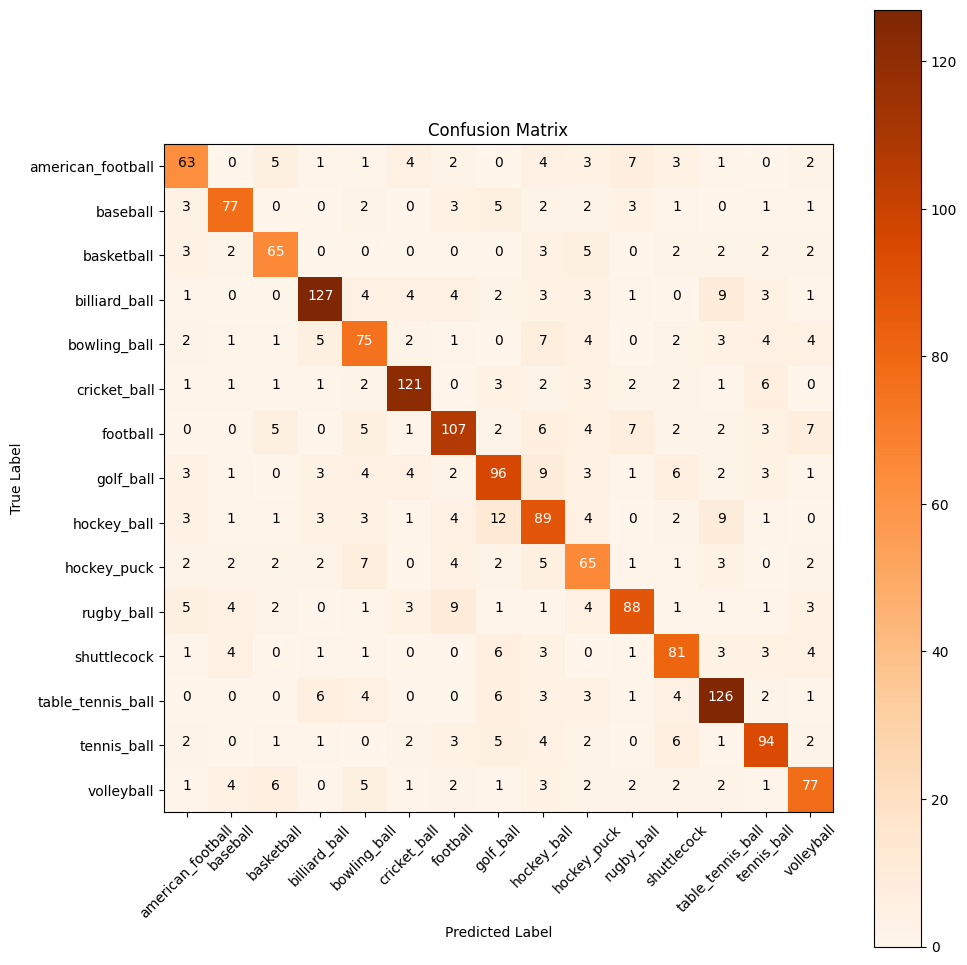

In [28]:
preds = model_new.predict_generator(test_data)
y_pred = np.argmax(preds, axis=1)
print(y_pred)
target_names = ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball',
                'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock',
                'table_tennis_ball', 'tennis_ball', 'volleyball']
# Classification report
logger.info(classification_report(test_data.classes, y_pred, target_names=target_names))

fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_confusion_mat.png")
# Confusion matrix
cm = confusion_matrix(test_data.classes, y_pred)
plot_confusion_matrix(cm=cm, classes=target_names, title='Confusion Matrix', figname=fig_name)




In [29]:
# Save everything
acc = test_score[1] * 100
save_path = checkpoints_dir

# Save history
history_filename = f"{logs_text_dir}/{model_sel}-{current_timestamp}.npy"
np.save(history_filename, training_exper_model_eff.history)

logger.info(f'model training history was saved as {history_filename}')

# Save model
save_id = str(f'{exp_save_name}-{"%.2f" % round(acc, 2)}.h5')
model_save_loc = os.path.join(save_path, save_id)
model_new.save(model_save_loc)
logger.info(f'model was saved as {model_save_loc}')

# Save weights
weight_save_id = str(f'{exp_save_name}-{"%.2f" % round(acc, 2)}-weights.h5')
weights_save_loc = os.path.join(save_path, weight_save_id)
model_new.save_weights(weights_save_loc)
logger.info(f'weights were saved as {weights_save_loc}')

elapsed_time = time.time() - start_time
logger.info(f"{current_timestamp}: Processing time: {elapsed_time} seconds. Saved plot to {fig_name} \n")
logger.info(time.strftime("%H:%M:%S", time.gmtime(elapsed_time)))
logger.info(f"Finished!")


2024-12-20 05:40:49,858 - INFO - model training history was saved as ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/logs/ModelCNNExp1-20241220-054044.npy
/home/phuocddat/git-repo/msc_ai/chest_xray/env_chest_xray/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2024-12-20 05:40:49,961 - INFO - model was saved as ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/checkpoints/20241220-043409___model_ModelCNNExp1_config_5_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug-68.75.h5
2024-12-20 05:40:50,002 - INFO - weights were saved as ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/checkpoints/20241220-043409___model_ModelCNNExp1_config_5_imagenet_frozen_Adamax_bs_16_frozen_False_cosine__aug-68.75-weights.h5
2024-12-20 05:40:50,002 - INFO - 20241220-054044

In [30]:
## Train second round with stronger augmentation data

In [31]:
# Reinitiate setting

In [32]:
epochs = 100
learning_rate = 0.001
# learning cosine decay rate
decay_rate = 0.75
decay_alpha_value = 0.1
total_steps = len(train_data) * epochs
decay_steps = total_steps * decay_rate
logger.info(f"Total steps: {total_steps}"
      f"\n_decay steps: {decay_steps}")

cosine_decay_scheduler = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=learning_rate,
    decay_steps=decay_steps,
    alpha=decay_alpha_value
)
my_callbacks_2 = [
    # keras.callbacks.EarlyStopping(patience=enableEarlyStopping_threshold) if enableEarlyStopping else None,
    LearningRateLogger(),
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_accuracy',
        mode='max',
        save_best_only=True
    )
]

2024-12-20 05:40:50,041 - INFO - Total steps: 32100
_decay steps: 24075.0


In [33]:
augmentation_opts_second = {
            'rescale': 1./255., # Remember to set None if model is EfficientNet
            'rotation_range': 5,
            'width_shift_range': 0.1,
            'height_shift_range': 0.1,
            'zoom_range': 0.3,
            'horizontal_flip': True,
            'vertical_flip': True,
        }
train_data_2, val_data_2, test_data_2 = dev_dataprocesses.data_generators(
    datasource=loaded_datasets,
    data_generator='keras',
    test_split_value = test_split_value,
    val_split_value = val_split_value,
    randomState_value = randomState_value,
    default_xcol_value = default_xcol_value,
    default_ycol_value = default_ycol_value,
    batch_size = batch_size,
    isShuffle = isShuffle,
    augmentation_opts = augmentation_opts_second
)
class_weights = {}
unique_classes = None
class_weights_np = None
unique_classes = np.unique(train_data_2.classes)
class_weights_np = class_weight.compute_class_weight(class_weight = 'balanced', classes = unique_classes,y=train_data_2.classes)
class_weights = {l:c for l,c in zip(unique_classes, class_weights_np)}

 processing from datasources:
 datasource: 3
3
data split train
                                            filepath     label
0  ./datasets/sport-balls/train/baseball/baseball...  baseball
1  ./datasets/sport-balls/train/baseball/baseball...  baseball
2  ./datasets/sport-balls/train/baseball/baseball...  baseball
3  ./datasets/sport-balls/train/baseball/baseball...  baseball
4  ./datasets/sport-balls/train/baseball/baseball...  baseball
(7328, 2)
label
billiard_ball        646
table_tennis_ball    620
football             604
cricket_ball         581
golf_ball            549
hockey_ball          530
rugby_ball           493
tennis_ball          490
bowling_ball         440
volleyball           432
shuttlecock          429
baseball             400
hockey_puck          390
american_football    384
basketball           340
Name: count, dtype: int64
data split test
                                            filepath     label
0  ./datasets/sport-balls/test/baseball/baseball_...  baseball

In [34]:

start_time_2 = time.time()
training_exper_model_eff_2 = model_new.fit(train_data_2,
                                         epochs=epochs,
                                         validation_data=val_data_2,
                                         verbose=1,
                                         callbacks=my_callbacks_2,
                                           class_weight=class_weights
                                         #use_multiprocessing = True
                                         )
logger.info(f"Training finished in {time.time() - start_time_2} seconds")

Epoch 1/100
321/321 [==============================] - 52s 163ms/step - loss: 0.3270 - accuracy: 0.9359 - val_loss: 1.9754 - val_accuracy: 0.7012 - learning_rate: 1.0000e-04
Epoch 2/100


/home/phuocddat/git-repo/msc_ai/chest_xray/env_chest_xray/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


321/321 [==============================] - 52s 163ms/step - loss: 0.3055 - accuracy: 0.9329 - val_loss: 2.0068 - val_accuracy: 0.7067 - learning_rate: 1.0000e-04
Epoch 3/100
321/321 [==============================] - 52s 163ms/step - loss: 0.2844 - accuracy: 0.9355 - val_loss: 1.9639 - val_accuracy: 0.7058 - learning_rate: 1.0000e-04
Epoch 4/100
321/321 [==============================] - 52s 162ms/step - loss: 0.2989 - accuracy: 0.9359 - val_loss: 1.9777 - val_accuracy: 0.6930 - learning_rate: 1.0000e-04
Epoch 5/100
321/321 [==============================] - 52s 163ms/step - loss: 0.3013 - accuracy: 0.9335 - val_loss: 1.9790 - val_accuracy: 0.7035 - learning_rate: 1.0000e-04
Epoch 6/100
321/321 [==============================] - 52s 163ms/step - loss: 0.2890 - accuracy: 0.9392 - val_loss: 1.8673 - val_accuracy: 0.6930 - learning_rate: 1.0000e-04
Epoch 7/100
321/321 [==============================] - 52s 163ms/step - loss: 0.2641 - accuracy: 0.9440 - val_loss: 1.8646 - val_accuracy: 0.7

2024-12-20 07:07:59,588 - INFO - Training finished in 5229.484274625778 seconds


In [35]:
## Evaluating 2
# Full Evaluate model
ts_length_2 = len(test_data_2)
test_batch_size_2 = max(
    sorted([ts_length_2 // n for n in range(1, ts_length_2 + 1) if ts_length_2 % n == 0 and ts_length_2 / n <= 80]))
test_steps_2 = ts_length_2 // test_batch_size_2

train_score_2 = model_new.evaluate(train_data_2, steps=test_steps, verbose=1)
valid_score_2 = model_new.evaluate(val_data_2, steps=test_steps, verbose=1)
test_score_2 = model_new.evaluate(test_data_2, steps=test_steps, verbose=1)
print("Train Loss: ", train_score_2[0])
print("Train Accuracy: ", train_score_2[1])
print('-' * 20)
print("Validation Loss: ", valid_score_2[0])
print("Validation Accuracy: ", valid_score_2[1])
print('-' * 20)
print("Test Loss: ", test_score_2[0])
print("Test Accuracy: ", test_score_2[1])

2/2 [==============================] - 0s 41ms/step - loss: 2.0311 - accuracy: 0.6875
Train Loss:  0.09510982036590576
Train Accuracy:  1.0
--------------------
Validation Loss:  2.4570484161376953
Validation Accuracy:  0.625
--------------------
Test Loss:  2.031083106994629
Test Accuracy:  0.6875


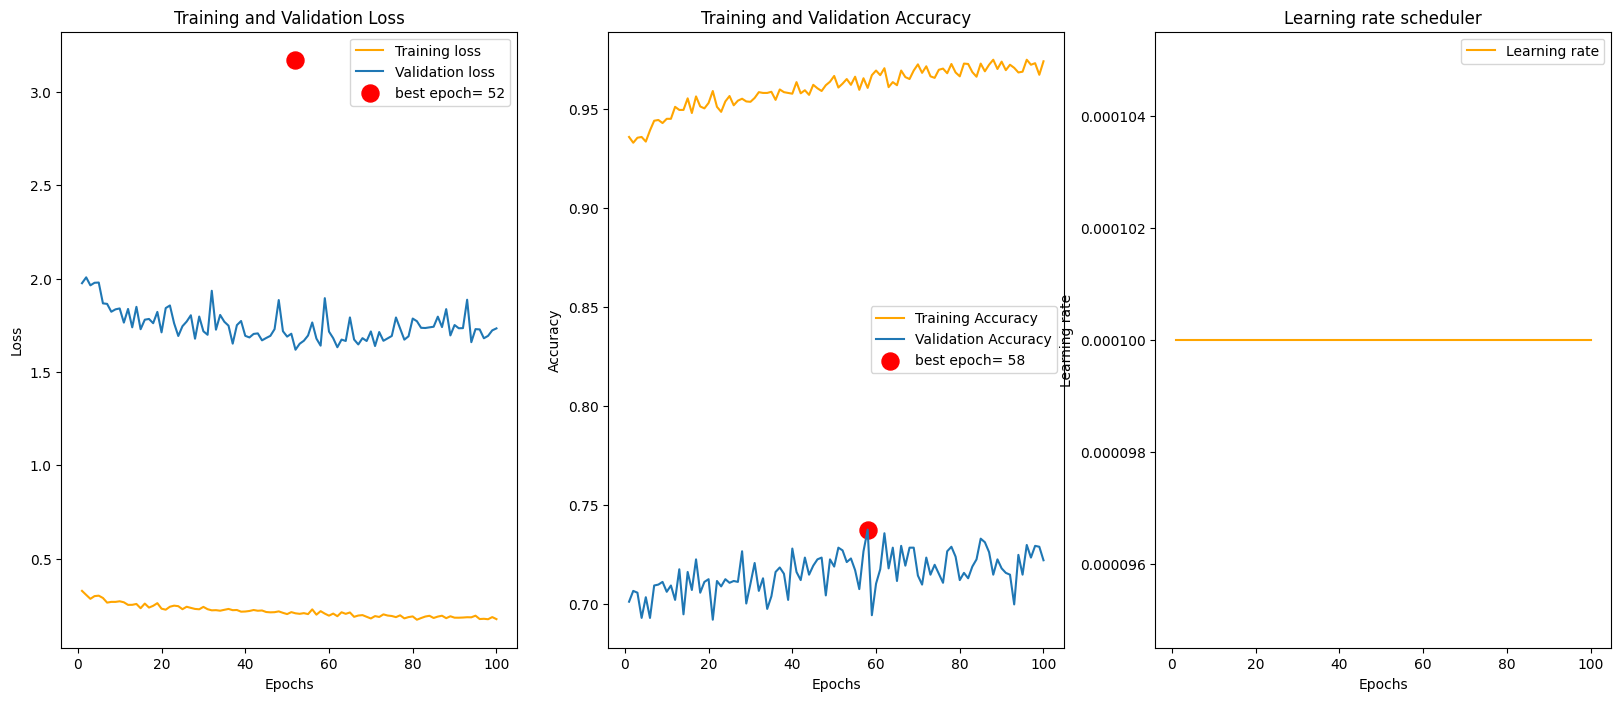

2024-12-20 07:08:01,324 - INFO - Export plot results: ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/logs/20241220-054044_aug_model_ModelCNNExp1_imagenet_frozen_False_ep100_bs_32_cosine_decay_scheduler_accuracy_loss_extra_trainacc_tr1.0_va0.78125_te0.6875_plots.png
2024-12-20 07:08:01,324 - INFO - Train loss: 0.09510982036590576
Train Accuracy: 1.0
Validation loss: 2.4570484161376953
Validation Accuracy: 0.625
Test Loss: 2.031083106994629
Test Accuracy: 0.6875


In [36]:
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_extra_train"
            f"{metrics_string}"
            f"_plots.png")
# Define needed variables
tr_acc_2 = training_exper_model_eff_2.history['accuracy']
tr_loss_2 = training_exper_model_eff_2.history['loss']
val_acc_2 = training_exper_model_eff_2.history['val_accuracy']
val_loss_2 = training_exper_model_eff_2.history['val_loss']

learning_rate_logs_2 = training_exper_model_eff_2.history['learning_rate']

index_loss_2 = np.argmin(val_loss_2)
val_lowest_2 = val_loss[index_loss_2]
index_acc_2 = np.argmax(val_acc_2)
acc_highest_2 = val_acc_2[index_acc_2]
# index_lr = np.argmin(learning_rate)

loss_label = f'best epoch= {str(index_loss_2 + 1)}'
acc_label = f'best epoch= {str(index_acc_2 + 1)}'

Epochs_2 = [i + 1 for i in range(len(tr_acc_2))]

# Plot training history
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.plot(Epochs_2, tr_loss_2, 'orange', label='Training loss')
plt.plot(Epochs_2, val_loss_2, label='Validation loss')
plt.scatter(index_loss_2 + 1, val_lowest_2, s=150, c='red', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(Epochs_2, tr_acc_2, 'orange', label='Training Accuracy')
plt.plot(Epochs_2, val_acc_2, label='Validation Accuracy')
plt.scatter(index_acc_2 + 1, acc_highest_2, s=150, c='red', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(Epochs_2, learning_rate_logs_2, 'orange', label='Learning rate')
plt.title('Learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.legend()
plt.savefig(fig_name)
plt.show()

logger.info(f"Export plot results: {fig_name}")

try:
    logger.info(f"Train loss: {train_score_2[0]}"
                f"\nTrain Accuracy: {train_score_2[1]}"
                f"\nValidation loss: {valid_score_2[0]}"
                f"\nValidation Accuracy: {valid_score_2[1]}"
                f"\nTest Loss: {test_score_2[0]}"
                f"\nTest Accuracy: {test_score_2[1]}")
except Exception as e:
    print(f"Unable to log evaluation score"
          f"\n Reason: {e}")

/tmp/ipykernel_1574297/3506886488.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds_2 = model_new.predict_generator(test_data_2)
2024-12-20 07:08:04,628 - INFO -                    precision    recall  f1-score   support

american_football       0.67      0.75      0.71        96
         baseball       0.91      0.78      0.84       100
       basketball       0.58      0.73      0.65        86
    billiard_ball       0.90      0.74      0.81       162
     bowling_ball       0.60      0.76      0.67       111
     cricket_ball       0.89      0.73      0.80       146
         football       0.66      0.75      0.70       151
        golf_ball       0.73      0.67      0.70       138
      hockey_ball       0.63      0.67      0.65       133
      hockey_puck       0.53      0.69      0.60        98
       rugby_ball       0.72      0.65      0.68       124
      shuttlecoc

[ 6 10  4 ...  7  8  9]
Confusion Matrix, Without Normalization
[[ 63   0   5   1   1   4   2   0   4   3   7   3   1   0   2]
 [  3  77   0   0   2   0   3   5   2   2   3   1   0   1   1]
 [  3   2  65   0   0   0   0   0   3   5   0   2   2   2   2]
 [  1   0   0 127   4   4   4   2   3   3   1   0   9   3   1]
 [  2   1   1   5  75   2   1   0   7   4   0   2   3   4   4]
 [  1   1   1   1   2 121   0   3   2   3   2   2   1   6   0]
 [  0   0   5   0   5   1 107   2   6   4   7   2   2   3   7]
 [  3   1   0   3   4   4   2  96   9   3   1   6   2   3   1]
 [  3   1   1   3   3   1   4  12  89   4   0   2   9   1   0]
 [  2   2   2   2   7   0   4   2   5  65   1   1   3   0   2]
 [  5   4   2   0   1   3   9   1   1   4  88   1   1   1   3]
 [  1   4   0   1   1   0   0   6   3   0   1  81   3   3   4]
 [  0   0   0   6   4   0   0   6   3   3   1   4 126   2   1]
 [  2   0   1   1   0   2   3   5   4   2   0   6   1  94   2]
 [  1   4   6   0   5   1   2   1   3   2   2   2   2 

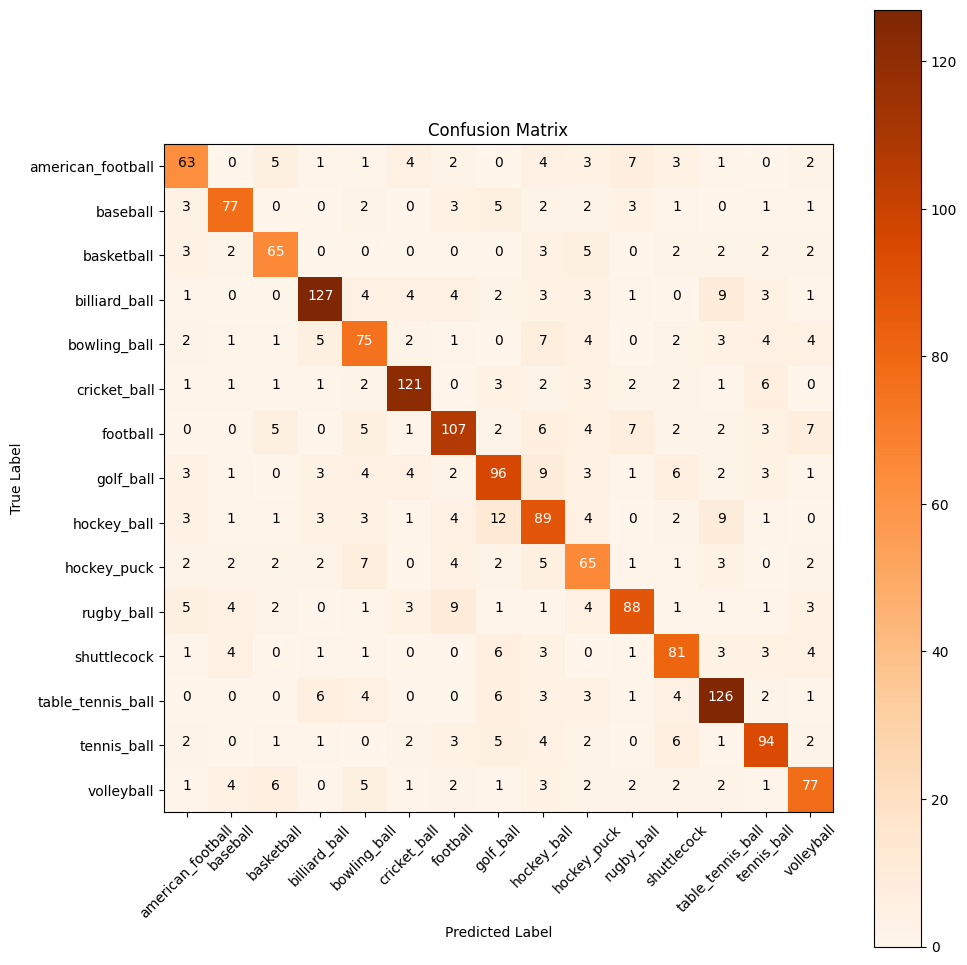

In [37]:
preds_2 = model_new.predict_generator(test_data_2)
y_pred_2 = np.argmax(preds_2, axis=1)
print(y_pred_2)
target_names = ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball',
                'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock',
                'table_tennis_ball', 'tennis_ball', 'volleyball']
# Classification report
logger.info(classification_report(test_data_2.classes, y_pred_2, target_names=target_names))

fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_confusion_mat_extra_train_2.png")
# Confusion matrix
cm_2 = confusion_matrix(test_data_2.classes, y_pred)
plot_confusion_matrix(cm=cm_2, classes=target_names, title='Confusion Matrix', figname=fig_name)

In [38]:
train_data_3, val_data_3, test_data_3 = dev_dataprocesses.data_generators(
    datasource=loaded_datasets,
    data_generator='keras',
    test_split_value = test_split_value,
    val_split_value = val_split_value,
    randomState_value = randomState_value,
    default_xcol_value = default_xcol_value,
    default_ycol_value = default_ycol_value,
    batch_size = batch_size,
    isShuffle = isShuffle,
    augmentation_opts = augmentation_opts_second
)

 processing from datasources:
 datasource: 3
3
data split train
                                            filepath     label
0  ./datasets/sport-balls/train/baseball/baseball...  baseball
1  ./datasets/sport-balls/train/baseball/baseball...  baseball
2  ./datasets/sport-balls/train/baseball/baseball...  baseball
3  ./datasets/sport-balls/train/baseball/baseball...  baseball
4  ./datasets/sport-balls/train/baseball/baseball...  baseball
(7328, 2)
label
billiard_ball        646
table_tennis_ball    620
football             604
cricket_ball         581
golf_ball            549
hockey_ball          530
rugby_ball           493
tennis_ball          490
bowling_ball         440
volleyball           432
shuttlecock          429
baseball             400
hockey_puck          390
american_football    384
basketball           340
Name: count, dtype: int64
data split test
                                            filepath     label
0  ./datasets/sport-balls/test/baseball/baseball_...  baseball

In [39]:
class_weights = {}
unique_classes = None
class_weights_np = None
unique_classes = np.unique(train_data_3.classes)
class_weights_np = class_weight.compute_class_weight(class_weight = 'balanced', classes = unique_classes,y=train_data_3.classes)
class_weights = {l:c for l,c in zip(unique_classes, class_weights_np)}

logger.info(f"Class weights {class_weights}")

2024-12-20 07:08:05,374 - INFO - Class weights {0: 1.305089058524173, 1: 1.1670079635949944, 2: 1.3622841965471448, 3: 0.7417208966015908, 4: 1.1435897435897435, 5: 0.8121931908155187, 6: 0.8083530338849487, 7: 0.8835486649440137, 8: 0.9471837488457987, 9: 1.2711276332094177, 10: 0.9939922480620155, 11: 1.2082449941107185, 12: 0.7878648233486943, 13: 0.9911111111111112, 14: 1.1551801801801802}


In [40]:
np.unique(train_data_3.classes)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [41]:
class_weights

{0: 1.305089058524173,
 1: 1.1670079635949944,
 2: 1.3622841965471448,
 3: 0.7417208966015908,
 4: 1.1435897435897435,
 5: 0.8121931908155187,
 6: 0.8083530338849487,
 7: 0.8835486649440137,
 8: 0.9471837488457987,
 9: 1.2711276332094177,
 10: 0.9939922480620155,
 11: 1.2082449941107185,
 12: 0.7878648233486943,
 13: 0.9911111111111112,
 14: 1.1551801801801802}

In [42]:
start_time_3 = time.time()
training_exper_model_eff_3 = model_new.fit(train_data_3,
                                         epochs=epochs,
                                         validation_data=val_data_3,
                                         verbose=1,
                                         callbacks=my_callbacks_2,
                                           class_weight=class_weights
                                         #use_multiprocessing = True
                                         )
logger.info(f"Training finished in {time.time() - start_time_2} seconds")

Epoch 1/100
321/321 [==============================] - 52s 162ms/step - loss: 0.1758 - accuracy: 0.9735 - val_loss: 1.7043 - val_accuracy: 0.7299 - learning_rate: 1.0000e-04
Epoch 2/100
321/321 [==============================] - 52s 163ms/step - loss: 0.1913 - accuracy: 0.9632 - val_loss: 1.7506 - val_accuracy: 0.7281 - learning_rate: 1.0000e-04
Epoch 3/100
321/321 [==============================] - 52s 162ms/step - loss: 0.1727 - accuracy: 0.9733 - val_loss: 1.6842 - val_accuracy: 0.7285 - learning_rate: 1.0000e-04
Epoch 4/100
321/321 [==============================] - 52s 162ms/step - loss: 0.1649 - accuracy: 0.9756 - val_loss: 1.7481 - val_accuracy: 0.7203 - learning_rate: 1.0000e-04
Epoch 5/100
321/321 [==============================] - 52s 163ms/step - loss: 0.1716 - accuracy: 0.9754 - val_loss: 1.7403 - val_accuracy: 0.7253 - learning_rate: 1.0000e-04
Epoch 6/100
321/321 [==============================] - 52s 162ms/step - loss: 0.1776 - accuracy: 0.9745 - val_loss: 1.7521 - val_a

/home/phuocddat/git-repo/msc_ai/chest_xray/env_chest_xray/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


321/321 [==============================] - 52s 162ms/step - loss: 0.1751 - accuracy: 0.9721 - val_loss: 1.7697 - val_accuracy: 0.7203 - learning_rate: 1.0000e-04
Epoch 18/100
321/321 [==============================] - 52s 163ms/step - loss: 0.1686 - accuracy: 0.9745 - val_loss: 1.7221 - val_accuracy: 0.7303 - learning_rate: 1.0000e-04
Epoch 19/100
321/321 [==============================] - 52s 162ms/step - loss: 0.1717 - accuracy: 0.9727 - val_loss: 1.7481 - val_accuracy: 0.7231 - learning_rate: 1.0000e-04
Epoch 20/100
321/321 [==============================] - 52s 162ms/step - loss: 0.1688 - accuracy: 0.9745 - val_loss: 1.7461 - val_accuracy: 0.7281 - learning_rate: 1.0000e-04
Epoch 21/100
321/321 [==============================] - 52s 162ms/step - loss: 0.1696 - accuracy: 0.9754 - val_loss: 1.7816 - val_accuracy: 0.7167 - learning_rate: 1.0000e-04
Epoch 22/100
321/321 [==============================] - 52s 162ms/step - loss: 0.1713 - accuracy: 0.9752 - val_loss: 1.7713 - val_accuracy

2024-12-20 08:34:59,117 - INFO - Training finished in 10449.013171672821 seconds


In [43]:
## Evaluating 3
# Full Evaluate model
ts_length_3 = len(test_data_3)
test_batch_size_3 = max(
    sorted([ts_length_3 // n for n in range(1, ts_length_3 + 1) if ts_length_3 % n == 0 and ts_length_3 / n <= 80]))
test_steps_3 = ts_length_3 // test_batch_size_3

train_score_3 = model_new.evaluate(train_data_3, steps=test_steps, verbose=1)
valid_score_3 = model_new.evaluate(val_data_3, steps=test_steps, verbose=1)
test_score_3 = model_new.evaluate(test_data_3, steps=test_steps, verbose=1)
print("Train Loss: ", train_score_3[0])
print("Train Accuracy: ", train_score_3[1])
print('-' * 20)
print("Validation Loss: ", valid_score_3[0])
print("Validation Accuracy: ", valid_score_3[1])
print('-' * 20)
print("Test Loss: ", test_score_3[0])
print("Test Accuracy: ", test_score_3[1])
metrics_string = f"acc_tr{train_score_3[1]}_va{valid_score_3[1]}_te{test_score_3[1]}"

2/2 [==============================] - 0s 38ms/step - loss: 2.0017 - accuracy: 0.7500
Train Loss:  0.08667223155498505
Train Accuracy:  1.0
--------------------
Validation Loss:  1.2893285751342773
Validation Accuracy:  0.75
--------------------
Test Loss:  2.0016841888427734
Test Accuracy:  0.75


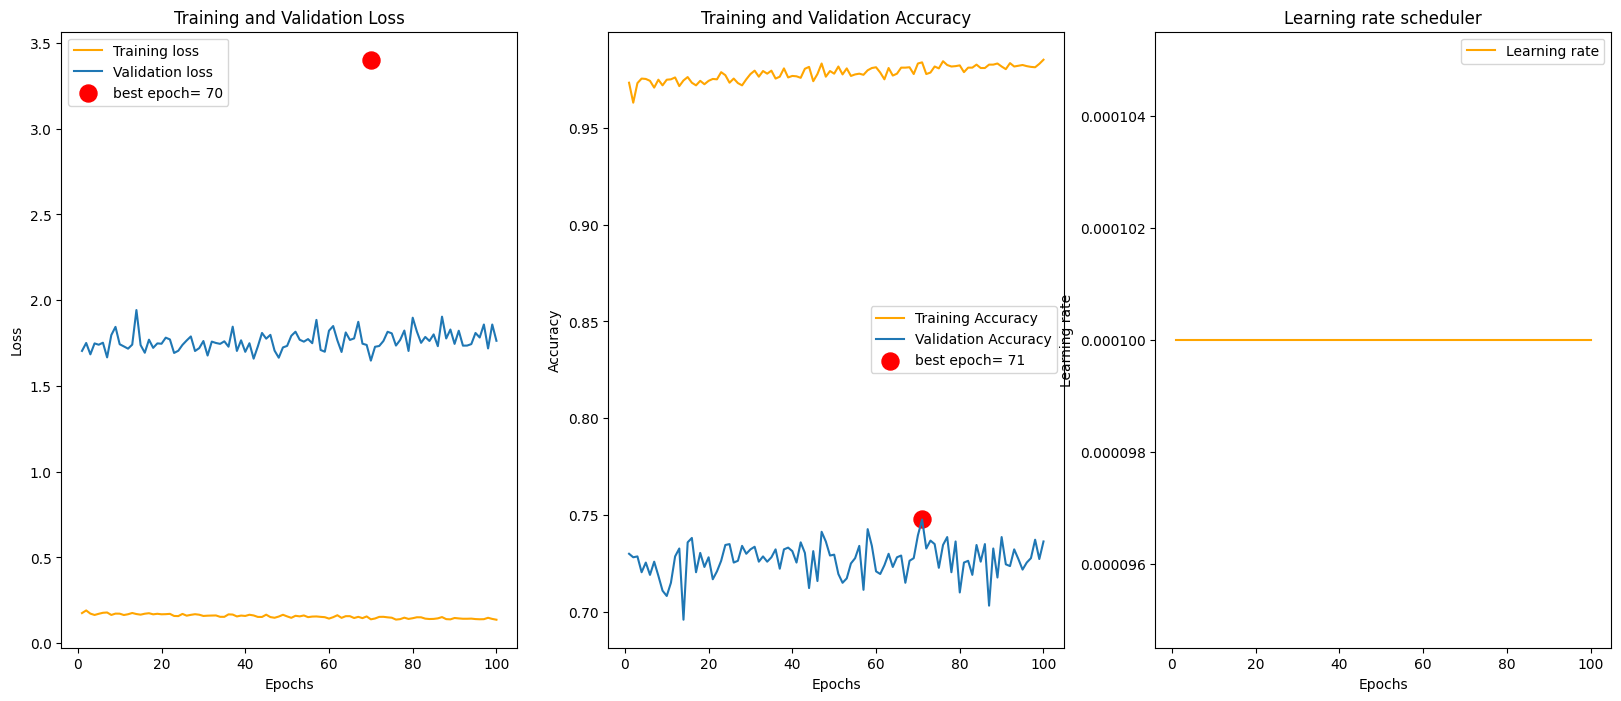

2024-12-20 08:35:00,802 - INFO - Export plot results: ./experiments/ModelCNNExp1-20241220_WYL2LDPVR/logs/20241220-054044_aug_model_ModelCNNExp1_imagenet_frozen_False_ep100_bs_32_cosine_decay_scheduler_accuracy_loss_extra_trainacc_tr1.0_va0.75_te0.75_plots.png
2024-12-20 08:35:00,802 - INFO - Train loss: 0.08667223155498505
Train Accuracy: 1.0
Validation loss: 1.2893285751342773
Validation Accuracy: 0.75
Test Loss: 2.0016841888427734
Test Accuracy: 0.75


In [44]:
fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_extra_train"
            f"{metrics_string}"
            f"_plots.png")
# Define needed variables
tr_acc_3 = training_exper_model_eff_3.history['accuracy']
tr_loss_3 = training_exper_model_eff_3.history['loss']
val_acc_3 = training_exper_model_eff_3.history['val_accuracy']
val_loss_3 = training_exper_model_eff_3.history['val_loss']

learning_rate_logs_3 = training_exper_model_eff_3.history['learning_rate']

index_loss_3 = np.argmin(val_loss_3)
val_lowest_3 = val_loss[index_loss_3]
index_acc_3 = np.argmax(val_acc_3)
acc_highest_3 = val_acc_3[index_acc_3]
# index_lr = np.argmin(learning_rate)

loss_label = f'best epoch= {str(index_loss_3 + 1)}'
acc_label = f'best epoch= {str(index_acc_3 + 1)}'

Epochs_3 = [i + 1 for i in range(len(tr_acc_3))]

# Plot training history
plt.figure(figsize=(20, 8))

plt.subplot(1, 3, 1)
plt.plot(Epochs_3, tr_loss_3, 'orange', label='Training loss')
plt.plot(Epochs_3, val_loss_3, label='Validation loss')
plt.scatter(index_loss_3 + 1, val_lowest_3, s=150, c='red', label=loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(Epochs_3, tr_acc_3, 'orange', label='Training Accuracy')
plt.plot(Epochs_3, val_acc_3, label='Validation Accuracy')
plt.scatter(index_acc_3 + 1, acc_highest_3, s=150, c='red', label=acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(Epochs_3, learning_rate_logs_3, 'orange', label='Learning rate')
plt.title('Learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Learning rate')
plt.legend()
plt.savefig(fig_name)
plt.show()

logger.info(f"Export plot results: {fig_name}")

try:
    logger.info(f"Train loss: {train_score_3[0]}"
                f"\nTrain Accuracy: {train_score_3[1]}"
                f"\nValidation loss: {valid_score_3[0]}"
                f"\nValidation Accuracy: {valid_score_3[1]}"
                f"\nTest Loss: {test_score_3[0]}"
                f"\nTest Accuracy: {test_score_3[1]}")
except Exception as e:
    print(f"Unable to log evaluation score"
          f"\n Reason: {e}")

/tmp/ipykernel_1574297/4141674390.py:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  preds_3 = model_new.predict_generator(test_data_3)
2024-12-20 08:35:04,194 - INFO -                    precision    recall  f1-score   support

american_football       0.66      0.72      0.69        96
         baseball       0.84      0.81      0.82       100
       basketball       0.62      0.79      0.70        86
    billiard_ball       0.86      0.75      0.80       162
     bowling_ball       0.58      0.66      0.62       111
     cricket_ball       0.93      0.75      0.83       146
         football       0.73      0.75      0.74       151
        golf_ball       0.75      0.70      0.72       138
      hockey_ball       0.59      0.68      0.63       133
      hockey_puck       0.69      0.67      0.68        98
       rugby_ball       0.67      0.69      0.68       124
      shuttlecoc

[ 1 10 10 ...  7 10  7]
Confusion Matrix, Without Normalization
[[ 63   0   5   1   1   4   2   0   4   3   7   3   1   0   2]
 [  3  77   0   0   2   0   3   5   2   2   3   1   0   1   1]
 [  3   2  65   0   0   0   0   0   3   5   0   2   2   2   2]
 [  1   0   0 127   4   4   4   2   3   3   1   0   9   3   1]
 [  2   1   1   5  75   2   1   0   7   4   0   2   3   4   4]
 [  1   1   1   1   2 121   0   3   2   3   2   2   1   6   0]
 [  0   0   5   0   5   1 107   2   6   4   7   2   2   3   7]
 [  3   1   0   3   4   4   2  96   9   3   1   6   2   3   1]
 [  3   1   1   3   3   1   4  12  89   4   0   2   9   1   0]
 [  2   2   2   2   7   0   4   2   5  65   1   1   3   0   2]
 [  5   4   2   0   1   3   9   1   1   4  88   1   1   1   3]
 [  1   4   0   1   1   0   0   6   3   0   1  81   3   3   4]
 [  0   0   0   6   4   0   0   6   3   3   1   4 126   2   1]
 [  2   0   1   1   0   2   3   5   4   2   0   6   1  94   2]
 [  1   4   6   0   5   1   2   1   3   2   2   2   2 

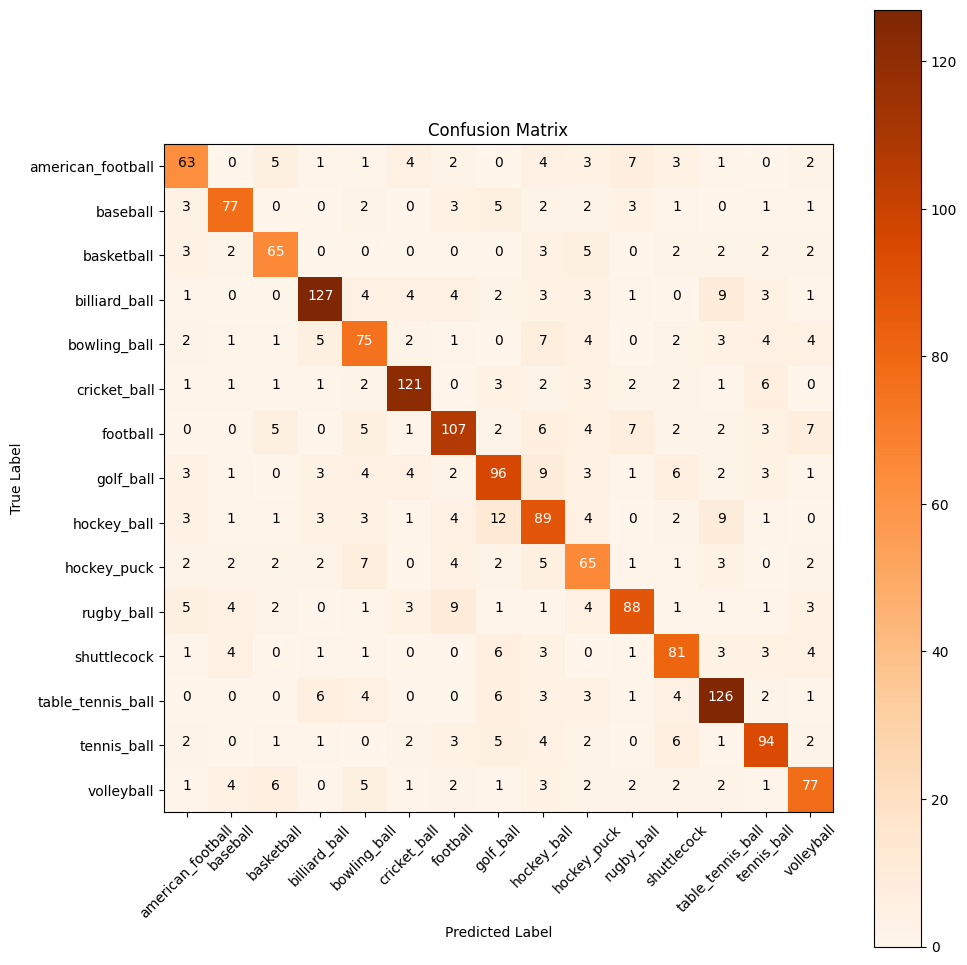

In [45]:
preds_3 = model_new.predict_generator(test_data_3)
y_pred_3 = np.argmax(preds_3, axis=1)
print(y_pred_3)
target_names = ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball',
                'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock',
                'table_tennis_ball', 'tennis_ball', 'volleyball']
# Classification report
logger.info(classification_report(test_data_3.classes, y_pred_3, target_names=target_names))

fig_name = (f"{logs_text_dir}/{current_timestamp}_"
            f"aug_"
            f"model_{model_sel}_{pretrained_weights}_frozen_{frozen_weights}_"
            f"ep{dev_configuration.epochs}_bs_{dev_configuration.batch_size}_cosine_decay_scheduler_accuracy_loss_"
            f"{metrics_string}"
            f"_confusion_mat_extra_train_3.png")
# Confusion matrix
cm_3 = confusion_matrix(test_data_3.classes, y_pred)
plot_confusion_matrix(cm=cm_3, classes=target_names, title='Confusion Matrix', figname=fig_name)